In [ ]:
!pip install torchviz torchinfo --quiet

In [ ]:
!pip install numpy==1.26.4
!pip install shapely pyproj folium
!pip install arcgis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 738.5/738.5 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 20.0 MB/s eta 0:00:00
  Created wheel for pylerc: filename=pylerc-4.0-py3-none-any.whl size=738090 sha256=589da111c80175ae59aacf38b1b84678a40864b5bcb84cd3d557a7d123cc2aa9
  Stored in directory: /root/.cache/pip/wheels/fa/44/c1/dee493b5ef79483d0276093205256ae13c97009c847e54c580
Successfully built pylerc
  Attempting uninstall: pyarrow
    Found exi

In [ ]:
# ============================================================
# Landslide Detection Training + Evaluation Script (Updated with ROC)
# ============================================================
import os
import random
from glob import glob
from tqdm import tqdm
import torchviz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
import torchvision.transforms.functional as TF
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve, auc
)

# ============================================================
# SETTINGS
# ============================================================
RUN_MODE = "evaluate"   # "train" or "evaluate"
DATA_DIR = "/content/drive/MyDrive/content/arrays"
MODEL_PATH = "best_model.pth"
BATCH_SIZE = 8
EPOCHS = 20
LR = 1e-4

# ============================================================
# Dataset
# ============================================================
class LandslideDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        arr = np.load(self.filepaths[idx]).astype(np.float32)
        arr = np.clip(arr, 0, None)
        for b in range(arr.shape[-1]):
            p2, p98 = np.percentile(arr[..., b], [2, 98])
            if p98 - p2 > 0:
                arr[..., b] = (arr[..., b] - p2) / (p98 - p2)
            else:
                arr[..., b] /= (arr[..., b].max() + 1e-6)

        tensor = torch.from_numpy(arr.transpose(2, 0, 1)).float()
        label = torch.tensor(self.labels[idx]).float()
        if self.transform:
            tensor, label = self.transform(tensor, label)
        return tensor, label

# ============================================================
# Simple Augmentation
# ============================================================
class SimpleAugment:
    def __call__(self, x, y):
        if random.random() < 0.5:
            x = TF.hflip(x) if random.random() < 0.5 else TF.vflip(x)
        if random.random() < 0.3:
            k = random.choice([1, 2, 3])
            x = torch.rot90(x, k, [1, 2])
        return x, y

# ============================================================
# Model (outputs probabilities)
# ============================================================
class SmallCNN(nn.Module):
    def __init__(self, in_ch=6):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, 1),
            nn.Sigmoid()  # outputs probability
        )

    def forward(self, x):
        return self.fc(self.conv(x)).squeeze(1)

# ============================================================
# Weighted BCELoss for class imbalance
# ============================================================
def weighted_bce_loss(probs, targets, pos_weight):
    weights = torch.ones_like(targets)
    weights[targets == 1] = pos_weight
    loss = nn.BCELoss(weight=weights)(probs, targets)
    return loss

# ============================================================
# Training / Validation helpers
# ============================================================
def train_one_epoch(model, loader, opt, pos_weight, device):
    model.train()
    total_loss = 0
    preds, trues = [], []

    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        opt.zero_grad()

        probs = model(x)
        loss = weighted_bce_loss(probs, y, pos_weight)
        loss.backward()
        opt.step()

        total_loss += loss.item() * x.size(0)
        preds.extend(probs.detach().cpu().numpy().tolist())
        trues.extend(y.detach().cpu().numpy().tolist())

    return total_loss / len(loader.dataset), preds, trues

def validate(model, loader, pos_weight, device):
    model.eval()
    total_loss = 0
    preds, trues = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            probs = model(x)
            loss = weighted_bce_loss(probs, y, pos_weight)
            total_loss += loss.item() * x.size(0)
            preds.extend(probs.cpu().numpy().tolist())
            trues.extend(y.cpu().numpy().tolist())

    return total_loss / len(loader.dataset), preds, trues

# ============================================================
# Confusion Matrix Plot
# ============================================================
def plot_confusion_matrix(y_true, y_pred_labels):
    cm = confusion_matrix(y_true, y_pred_labels)
    labels = ["Non-Landslide", "Landslide"]

    # Compute row percentages
    row_sums = cm.sum(axis=1, keepdims=True)
    pct = np.round(cm / (row_sums + 1e-9) * 100, 1)

    # Combine counts and percentages
    annot = np.array([f"{count}\n({pc}%)" for count, pc in zip(cm.flatten(), pct.flatten())])
    annot = annot.reshape(cm.shape)

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cm, cmap="RdBu", aspect="equal")

    # Add text annotations manually
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, annot[i, j],
                    ha="center", va="center", fontsize=11, color="white")

    # Axis labels and ticks
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Confusion Matrix")

    # Add colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Number of Samples")

    # ✅ Critical fix: ensure full matrix is drawn
    ax.set_xlim(-0.5, cm.shape[1]-0.5)
    ax.set_ylim(cm.shape[0]-0.5, -0.5)

    plt.tight_layout()
    plt.show()




# -------------------------
# Weighted Average Metrics Plot
# -------------------------
def plot_weighted_metrics(weighted, accuracy):
    metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
    values = [accuracy, weighted["precision"], weighted["recall"], weighted["f1-score"]]

    # Same colour style as your previous image
    colors = ["#0000FF", "#4CAF50", "#FFCA28", "#FF5252"]

    plt.figure(figsize=(7, 5))
    bars = plt.bar(metrics, values, color=colors, alpha=0.9)

    # Add text labels above bars
    for bar, val in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.02,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title("Weighted Average Performance Metrics - Test Set", fontweight="bold")
    plt.tight_layout()
    plt.show()

# ============================================================
# ROC Curve Plot
# ============================================================
def plot_roc(y_true, y_probs):
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # --------------------------------------------------------
    # Load dataset paths
    landslide_files = glob(f"{DATA_DIR}/*/landslide/*.npy", recursive=True)
    nonlandslide_files = glob(f"{DATA_DIR}/*/nonlandslide/*.npy", recursive=True)
    files = landslide_files + nonlandslide_files
    labels = [1]*len(landslide_files) + [0]*len(nonlandslide_files)

    # Split datasets
    train_files, temp_files, train_labels, temp_labels = train_test_split(
        files, labels, test_size=0.3, stratify=labels, random_state=42)
    val_files, test_files, val_labels, test_labels = train_test_split(
        temp_files, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42)

    print(f"Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")
    print(np.unique(test_labels, return_counts=True))

    # Create datasets/loaders
    train_ds = LandslideDataset(train_files, train_labels, transform=SimpleAugment())
    val_ds = LandslideDataset(val_files, val_labels)
    test_ds = LandslideDataset(test_files, test_labels)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # Model
    in_channels = np.load(files[0]).shape[-1]
    model = SmallCNN(in_ch=in_channels).to(device)

    # Calculate pos_weight for imbalance
    num_pos = sum(train_labels)
    num_neg = len(train_labels) - num_pos
    pos_weight = num_neg / (num_pos + 1e-6)
    pos_weight_tensor = torch.tensor([pos_weight], device=device)

    # Optimizer and scheduler
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------
    if RUN_MODE == "train":
        best_val_f1 = 0
        for epoch in range(1, EPOCHS+1):
            print(f"\nEpoch {epoch}")
            train_loss, _, _ = train_one_epoch(model, train_loader, opt, pos_weight_tensor, device)
            val_loss, val_preds, val_trues = validate(model, val_loader, pos_weight_tensor, device)
            val_pred_labels = (np.array(val_preds) >= 0.5).astype(int)
            val_f1 = f1_score(val_trues, val_pred_labels)
            print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")
            scheduler.step(val_loss)
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                torch.save(model.state_dict(), MODEL_PATH)
                print("✅ Saved best model.")

    # --------------------------------------------------------
    # EVALUATION
    # --------------------------------------------------------
    print("\n=== EVALUATION ON TEST SET ===")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    test_loss, test_preds, test_trues = validate(model, test_loader, pos_weight_tensor, device)
    test_pred_labels = (np.array(test_preds) >= 0.5).astype(int)

    test_f1 = f1_score(test_trues, test_pred_labels)
    test_acc = accuracy_score(test_trues, test_pred_labels)
    test_auc = roc_auc_score(test_trues, test_preds) if len(set(test_trues)) > 1 else np.nan
    print(f"Test Loss: {test_loss:.4f} | F1: {test_f1:.4f} | AUC: {test_auc:.4f} | Acc: {test_acc:.4f}")

    # Save CSV
    results_df = pd.DataFrame({
        "file": test_files,
        "true_label": test_trues,
        "predicted_prob": test_preds,
        "predicted_label": test_pred_labels
    })
    results_df.to_csv("test_predictions.csv", index=False)
    print("✅ Saved test_predictions.csv")

    # # Confusion matrix
    # plot_confusion_matrix(test_trues, test_pred_labels)

    # # ROC curve
    # plot_roc(test_trues, test_preds)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(test_trues, test_pred_labels,
                                target_names=["Non-Landslide", "Landslide"], digits=3))

    # Show some FP/FN examples
    fp = results_df[(results_df["true_label"] == 0) & (results_df["predicted_label"] == 1)]
    fn = results_df[(results_df["true_label"] == 1) & (results_df["predicted_label"] == 0)]

    print(f"\nFalse Positives: {len(fp)}")
    print(fp['file'].head().tolist())
    print(f"\nFalse Negatives: {len(fn)}")
    print(fn['file'].head().tolist())

    # -------------------------
    # Compute metrics
    # -------------------------
    acc = accuracy_score(test_trues, test_pred_labels)
    report = classification_report(
        test_trues,
        test_pred_labels,
        target_names=["Non-Landslide", "Landslide"],
        output_dict=True
    )
    weighted = report["weighted avg"]
    # plot_weighted_metrics(weighted, acc)

    # Print summary
    summary(model, input_size=(1, in_channels, 128, 128))


Train: 1780, Val: 382, Test: 382
(array([0, 1]), array([306,  76]))

=== EVALUATION ON TEST SET ===
Test Loss: 0.6899 | F1: 0.6162 | AUC: 0.8825 | Acc: 0.8010
✅ Saved test_predictions.csv

Classification Report:
               precision    recall  f1-score   support

Non-Landslide      0.942     0.801     0.866       306
    Landslide      0.500     0.803     0.616        76

     accuracy                          0.801       382
    macro avg      0.721     0.802     0.741       382
 weighted avg      0.854     0.801     0.816       382


False Positives: 61
['/content/drive/MyDrive/content/arrays/rodney/nonlandslide/northland_nonlands_984.npy', '/content/drive/MyDrive/content/arrays/rodney/nonlandslide/rodney_nonlands_276.npy', '/content/drive/MyDrive/content/arrays/rodney/nonlandslide/rodney_nonlands_301.npy', '/content/drive/MyDrive/content/arrays/rodney/nonlandslide/northland_nonlands_956.npy', '/content/drive/MyDrive/content/arrays/rodney/nonlandslide/northland_nonlands_434.npy']

In [ ]:
summary(model, input_size=(1, in_channels, 128, 128))

Layer (type:depth-idx)                   Output Shape              Param #
SmallCNN                                 [1]                       --
├─Sequential: 1-1                        [1, 256, 1, 1]            --
│    └─Conv2d: 2-1                       [1, 32, 128, 128]         1,760
│    └─BatchNorm2d: 2-2                  [1, 32, 128, 128]         64
│    └─ReLU: 2-3                         [1, 32, 128, 128]         --
│    └─MaxPool2d: 2-4                    [1, 32, 64, 64]           --
│    └─Conv2d: 2-5                       [1, 64, 64, 64]           18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 64, 64]           128
│    └─ReLU: 2-7                         [1, 64, 64, 64]           --
│    └─MaxPool2d: 2-8                    [1, 64, 32, 32]           --
│    └─Conv2d: 2-9                       [1, 128, 32, 32]          73,856
│    └─BatchNorm2d: 2-10                 [1, 128, 32, 32]          256
│    └─ReLU: 2-11                        [1, 128, 32, 32]          --
│ 

AOI approx shape: 555x673, size ~8.96 MB


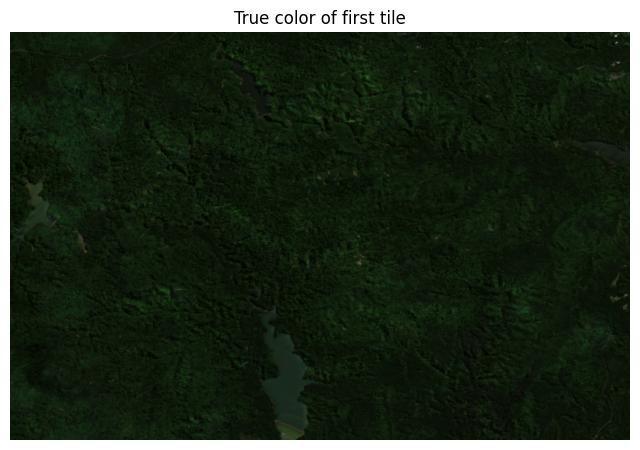

In [ ]:
import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt

# Initialize Earth Engine
ee.Authenticate()
ee.Initialize(project='apat260-geog-761')

# -----------------------
# AOI
# -----------------------
coords = [-36.99118, 174.532928, -36.941223, 174.608803]  # [lat_min, lon_min, lat_max, lon_max]
aoi = ee.Geometry.Rectangle([coords[1], coords[0], coords[3], coords[2]])

# -----------------------
# Sentinel-2 collection
# -----------------------
bands = ['B2','B3','B4','B8','B11','B12']
collection = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
              .filterBounds(aoi)
              .filterDate('2024-01-01','2024-12-31')
              .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
             )
image = collection.median().select(bands)

# -----------------------
# Tile-splitting parameters
# -----------------------
scale = 10  # 10m resolution
max_bytes = 50_000_000  # EE limit ~50MB per request
dtype_bytes = 4  # float32 per band
num_bands = len(bands)

# Calculate approximate AOI size in meters
lat_min, lon_min, lat_max, lon_max = coords
height_m = (lat_max - lat_min) * 111000  # ~meters per degree lat
width_m  = (lon_max - lon_min) * 111000 * np.cos(np.radians((lat_min+lat_max)/2))
pixels_height = int(np.ceil(height_m / scale))
pixels_width  = int(np.ceil(width_m / scale))
approx_bytes = pixels_height * pixels_width * num_bands * dtype_bytes

print(f"AOI approx shape: {pixels_height}x{pixels_width}, size ~{approx_bytes/1e6:.2f} MB")

# -----------------------
# Decide if we need tiling
# -----------------------
def split_aoi(aoi, nx, ny):
    coords = aoi.coordinates().getInfo()[0]  # [[xmin, ymin], [xmax, ymax], ...]
    xmin, ymin = coords[0]
    xmax, ymax = coords[2]
    x_step = (xmax - xmin) / nx
    y_step = (ymax - ymin) / ny
    tiles = []
    for i in range(nx):
        for j in range(ny):
            x0 = xmin + i*x_step
            x1 = xmin + (i+1)*x_step
            y0 = ymin + j*y_step
            y1 = ymin + (j+1)*y_step
            tiles.append(ee.Geometry.Rectangle([x0,y0,x1,y1]))
    return tiles

if approx_bytes > max_bytes:
    nx = int(np.ceil(np.sqrt(approx_bytes/max_bytes)))
    ny = nx
    print(f"Splitting AOI into {nx}x{ny} tiles")
    tiles = split_aoi(aoi, nx, ny)
else:
    tiles = [aoi]

# -----------------------
# Download each tile
# -----------------------
all_arrays = []
for idx, tile in enumerate(tiles):
    print(f"Downloading tile {idx+1}/{len(tiles)}...")
    array = geemap.ee_to_numpy(image, region=tile, scale=scale)
    np.save(f"tile_{idx}.npy", array)
    all_arrays.append(array)

# -----------------------
# Optional: stitch tiles into one array (if small enough)
# -----------------------
if len(all_arrays) == 1:
    final_array = all_arrays[0]
else:
    # Simple vertical/horizontal stacking if NxN tiles
    # Here we just leave tiles separate for safety
    final_array = None
    print("Tiles saved separately. Stitching skipped to avoid memory issues.")

# -----------------------
# Visualization example for first tile
# -----------------------
array = all_arrays[0]
if array.shape[0]==6:
    array = np.moveaxis(array,0,-1)
rgb = np.stack([array[:,:,2], array[:,:,1], array[:,:,0]], axis=-1)
rgb = np.clip(rgb/3000,0,1)

plt.figure(figsize=(8,8))
plt.imshow(rgb)
plt.title("True color of first tile")
plt.axis("off")
plt.show()

In [ ]:
Map = geemap.Map(center=[-36.97, 174.57], zoom=12)
vis_params = {
    'bands': ['B4', 'B3', 'B2'],   # true color
    'min': 0,
    'max': 3000,
    'gamma': 1.3
}
Map.addLayer(image, vis_params, 'Sentinel-2 True Color')
Map.addLayerControl()
Map

Map(center=[-36.97, 174.57], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchData…

Array shape: (557, 846, 6)


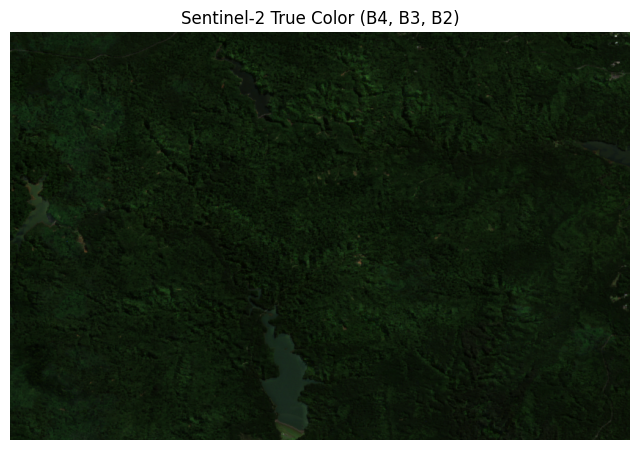

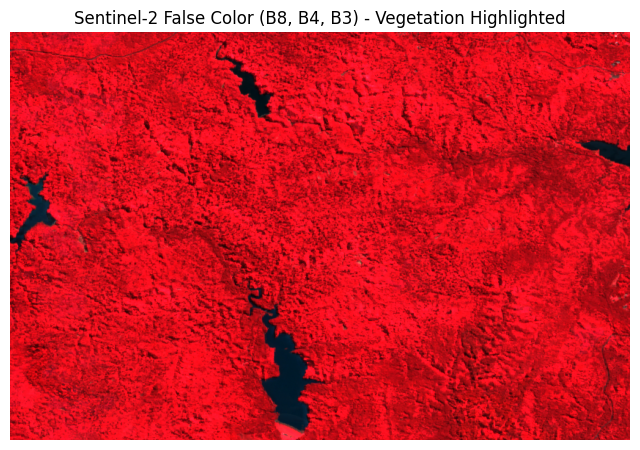

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1️⃣ Load the .npy file
# ------------------------------------------------------------
array = np.load("tile_0.npy")
print("Array shape:", array.shape)

# Expected shape: (rows, cols, 6) for [B2, B3, B4, B8, B11, B12]
# If shape is (6, rows, cols), just transpose:
if array.shape[0] == 6:
    array = np.moveaxis(array, 0, -1)

# ------------------------------------------------------------
# 2️⃣ True color composite (B4, B3, B2)
# ------------------------------------------------------------
rgb = np.stack([array[:, :, 2], array[:, :, 1], array[:, :, 0]], axis=-1)
rgb = np.clip(rgb / 3000, 0, 1)  # Scale reflectance roughly to 0–1

plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.title("Sentinel-2 True Color (B4, B3, B2)")
plt.axis("off")
plt.show()

# ------------------------------------------------------------
# 3️⃣ False color composite (B8, B4, B3)
# ------------------------------------------------------------
false_rgb = np.stack([array[:, :, 3], array[:, :, 2], array[:, :, 1]], axis=-1)
false_rgb = np.clip(false_rgb / 3000, 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(false_rgb)
plt.title("Sentinel-2 False Color (B8, B4, B3) - Vegetation Highlighted")
plt.axis("off")
plt.show()


In [ ]:
from arcgis.gis import GIS
from arcgis.features import FeatureLayer
from shapely.geometry import Polygon, Point, box
from pyproj import Transformer
import folium

gis = GIS()

# URLs
polygon_url = "https://services-ap1.arcgis.com/9R0qvCUXav3QPG1F/arcgis/rest/services/ValidatedLandslides/FeatureServer/2"
points_url = "https://services-ap1.arcgis.com/9R0qvCUXav3QPG1F/arcgis/rest/services/ValidatedLandslides/FeatureServer/0"

polygon_layer = FeatureLayer(polygon_url)
points_layer = FeatureLayer(points_url)

# Fetch features
polygons = polygon_layer.query(where="1=1", out_fields="*", result_record_count=2000).features
points = points_layer.query(where="1=1", out_fields="dateoccurence", result_record_count=2000).features

# Transformer from NZTM2000 (EPSG:2193) to WGS84 lat/lon (EPSG:4326)
transformer = Transformer.from_crs("epsg:2193", "epsg:4326", always_xy=True)

# Convert polygons to Shapely polygons (lon, lat)
polygon_shapes = []
for poly in polygons:
    for ring in poly.geometry['rings']:
        coords_lonlat = [transformer.transform(x, y) for x, y in ring]
        polygon_shapes.append((Polygon(coords_lonlat), poly.attributes))

# Convert points to Shapely points (lon, lat)
point_shapes = []
for pt in points:
    x, y = pt.geometry['x'], pt.geometry['y']
    lon, lat = transformer.transform(x, y)
    point_shapes.append((Point(lon, lat), pt.attributes.get("dateoccurence", "Unknown")))

# Spatial join: points inside polygons
polygon_dates = []
for poly, attrs in polygon_shapes:
    dates_inside = [date for pt, date in point_shapes if poly.contains(pt)]
    polygon_dates.append((poly, dates_inside))

# -----------------------
# AOI from Sentinel-2
# -----------------------
lat_min, lon_min, lat_max, lon_max = -36.99118, 174.532928, -36.941223, 174.608803
aoi_polygon = box(lon_min, lat_min, lon_max, lat_max)

# Filter polygons that intersect AOI
polygons_in_aoi = [(poly, dates) for poly, dates in polygon_dates if poly.intersects(aoi_polygon)]
points_in_aoi = [(pt, date) for pt, date in point_shapes if aoi_polygon.contains(pt)]

# Folium map centered on AOI
m = folium.Map(location=[(lat_min+lat_max)/2, (lon_min+lon_max)/2], zoom_start=13)

# Plot polygons in AOI with link to polygon layer
for i, (poly, dates) in enumerate(polygons_in_aoi):
    popup_text = f"Polygon {i+1}<br>Dates: {', '.join(dates) if dates else 'No landslides'}<br>"
    popup_text += f"<a href='{polygon_url}' target='_blank'>Polygon Layer Link</a>"
    folium.Polygon(
        locations=[(lat, lon) for lon, lat in poly.exterior.coords],
        color='red',
        weight=3,
        fill=True,
        fill_color='red',
        fill_opacity=0.5,
        popup=popup_text
    ).add_to(m)

# Plot points
for pt, date in points_in_aoi[:100]:
    folium.CircleMarker(
        location=[pt.y, pt.x],
        radius=4,
        color='green',
        fill=True,
        fill_color='green',
        fill_opacity=0.8,
        popup=str(date)
    ).add_to(m)

# Legend
legend_html = '''
<div style="
    position: fixed;
    bottom: 50px; left: 50px; width: 200px; height: 90px;
    background-color: white; z-index:9999; font-size:14px;
    border:2px solid grey; border-radius:5px; padding: 10px;
">
<b>Landslide Legend</b><br>
<span style="background-color:red;display:inline-block;width:15px;height:15px;margin-right:5px;"></span> Landslide Polygon<br>
<span style="background-color:green;display:inline-block;width:15px;height:15px;margin-right:5px;"></span> Landslide Point
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

m


In [ ]:
m

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import folium
from shapely.geometry import box, Polygon, Point
from pyproj import Transformer
from arcgis.gis import GIS
from arcgis.features import FeatureLayer
from PIL import Image
from folium.raster_layers import ImageOverlay
import matplotlib
import io
import base64

# ------------------------
# 1️⃣ Define CNN model
# ------------------------
class SmallCNN(torch.nn.Module):
    def __init__(self, in_ch=6):
        super().__init__()
        self.conv = torch.nn.Sequential(
            torch.nn.Conv2d(in_ch, 32, 3, padding=1), torch.nn.BatchNorm2d(32), torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(32, 64, 3, padding=1), torch.nn.BatchNorm2d(64), torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(64, 128, 3, padding=1), torch.nn.BatchNorm2d(128), torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(128, 256, 3, padding=1), torch.nn.BatchNorm2d(256), torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool2d(1)
        )
        self.fc = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(256, 64), torch.nn.ReLU(), torch.nn.Dropout(0.4),
            torch.nn.Linear(64, 1),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        return self.fc(self.conv(x)).squeeze(1)

# ------------------------
# 2️⃣ Load model
# ------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
in_channels = 6
model = SmallCNN(in_ch=in_channels).to(device)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

# ------------------------
# 3️⃣ Load AOI
# ------------------------
aoi_file = "tile_0.npy"  # replace with your AOI npy
aoi_array = np.load(aoi_file).astype(np.float32)

# # ------------------------
# # 4️⃣ Patch-wise prediction
# # ------------------------
# def predict_aoi_by_patches(aoi_array, model, patch_size=64, stride=32):
#     H, W, C = aoi_array.shape
#     prob_map = np.zeros((H,W), dtype=np.float32)
#     count_map = np.zeros((H,W), dtype=np.float32)

#     model.eval()
#     device = next(model.parameters()).device

#     for i in range(0, H-patch_size+1, stride):
#         for j in range(0, W-patch_size+1, stride):
#             patch = aoi_array[i:i+patch_size, j:j+patch_size, :].copy()
#             # Normalize per channel
#             for b in range(C):
#                 p2, p98 = np.percentile(patch[..., b], [2, 98])
#                 if p98 - p2 > 0:
#                     patch[..., b] = (patch[..., b] - p2) / (p98 - p2)
#                 else:
#                     patch[..., b] /= (patch[..., b].max() + 1e-6)
#             x = torch.from_numpy(patch.transpose(2,0,1)).unsqueeze(0).float().to(device)
#             with torch.no_grad():
#                 prob = model(x).cpu().item()
#             prob_map[i:i+patch_size, j:j+patch_size] += prob
#             count_map[i:i+patch_size, j:j+patch_size] += 1

#     prob_map /= np.maximum(count_map, 1)
#     return prob_map

# prob_map = predict_aoi_by_patches(aoi_array, model, patch_size=64, stride=32)
# ------------------------
# 4️⃣ Per-pixel prediction
# ------------------------
def predict_aoi_per_pixel(aoi_array, model):
    H, W, C = aoi_array.shape
    prob_map = np.zeros((H, W), dtype=np.float32)
    device = next(model.parameters()).device
    model.eval()

    for i in range(H):
        for j in range(W):
            pixel = aoi_array[i, j, :].copy()
            # Normalize per channel
            for b in range(C):
                p2, p98 = np.percentile(pixel[b], [2, 98]) if np.ndim(pixel[b])>0 else (pixel[b], pixel[b])
                if p98 - p2 > 0:
                    pixel[b] = (pixel[b] - p2) / (p98 - p2)
                else:
                    pixel[b] /= (pixel[b] + 1e-6)
            x = torch.from_numpy(pixel.astype(np.float32)).unsqueeze(0).unsqueeze(-1).unsqueeze(-1)  # [1,C,1,1]
            x = x.to(device)
            with torch.no_grad():
                prob = model(x).cpu().item()
            prob_map[i, j] = prob

    return prob_map

# Apply per-pixel prediction
prob_map = predict_aoi_per_pixel(aoi_array, model)
# ------------------------
# 5️⃣ Visualize probability map
# ------------------------
plt.figure(figsize=(8,8))
plt.imshow(prob_map, cmap='Reds')
plt.title("CNN Landslide Prediction")
plt.colorbar(label="Probability")
plt.axis('off')
plt.show()

# ------------------------
# 6️⃣ Load polygons & points
# ------------------------
gis = GIS()
polygon_url = "https://services-ap1.arcgis.com/9R0qvCUXav3QPG1F/arcgis/rest/services/ValidatedLandslides/FeatureServer/2"
points_url = "https://services-ap1.arcgis.com/9R0qvCUXav3QPG1F/arcgis/rest/services/ValidatedLandslides/FeatureServer/0"
polygon_layer = FeatureLayer(polygon_url)
points_layer = FeatureLayer(points_url)

polygons = polygon_layer.query(where="1=1", out_fields="*", result_record_count=2000).features
points = points_layer.query(where="1=1", out_fields="dateoccurence", result_record_count=2000).features

# ------------------------
# 7️⃣ Transform coordinates to WGS84
# ------------------------
transformer = Transformer.from_crs("epsg:2193","epsg:4326", always_xy=True)
polygon_shapes = []
for poly in polygons:
    for ring in poly.geometry['rings']:
        coords_lonlat = [transformer.transform(x,y) for x,y in ring]
        polygon_shapes.append((Polygon(coords_lonlat), poly.attributes))

point_shapes = []
for pt in points:
    x, y = pt.geometry['x'], pt.geometry['y']
    lon, lat = transformer.transform(x,y)
    point_shapes.append((Point(lon,lat), pt.attributes.get("dateoccurence","Unknown")))

# ------------------------
# 8️⃣ Filter polygons/points in AOI
# ------------------------
lat_min, lon_min, lat_max, lon_max = -36.99118, 174.532928, -36.941223, 174.608803
aoi_polygon = box(lon_min, lat_min, lon_max, lat_max)

polygons_in_aoi = [(poly, []) for poly,_ in polygon_shapes if poly.intersects(aoi_polygon)]
points_in_aoi = [(pt, date) for pt, date in point_shapes if aoi_polygon.contains(pt)]

# ------------------------
# 9️⃣ Create Folium map
# ------------------------
m = folium.Map(location=[(lat_min+lat_max)/2, (lon_min+lon_max)/2], zoom_start=13)

# Polygons
for i, (poly, _) in enumerate(polygons_in_aoi):
    folium.Polygon(
        locations=[(lat, lon) for lon, lat in poly.exterior.coords],
        color='red', weight=3,
        fill=True, fill_color='red', fill_opacity=0.5,
        popup=f"Polygon {i+1} <a href='{polygon_url}' target='_blank'>Link</a>"
    ).add_to(m)

# Points
for pt, date in points_in_aoi[:100]:
    folium.CircleMarker(
        location=[pt.y, pt.x],
        radius=4, color='green',
        fill=True, fill_color='green',
        fill_opacity=0.8,
        popup=str(date)
    ).add_to(m)

# AOI rectangle
folium.Polygon(
    locations=[(lat_min, lon_min),(lat_min, lon_max),(lat_max, lon_max),(lat_max, lon_min)],
    color='blue', weight=3, fill=False,
    popup="AOI"
).add_to(m)

# CNN probability overlay
pred_norm = (prob_map - prob_map.min()) / (prob_map.max()-prob_map.min())
cmap = matplotlib.colormaps["Reds"]
pred_rgba = cmap(pred_norm)
pred_rgba_uint8 = (pred_rgba*255).astype(np.uint8)
pred_img = Image.fromarray(pred_rgba_uint8)

# Convert to base64 for Folium
buffer = io.BytesIO()
pred_img.save(buffer, format="PNG")
buffer.seek(0)
img_b64 = base64.b64encode(buffer.read()).decode('utf-8')
data_uri = f"data:image/png;base64,{img_b64}"

ImageOverlay(
    image=data_uri,
    bounds=[[lat_min, lon_min],[lat_max, lon_max]],
    opacity=0.75,
    interactive=True
).add_to(m)

# Legend
legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; width: 220px; height: 100px;
background-color: white; z-index:9999; font-size:14px; border:2px solid grey; border-radius:5px; padding: 10px;">
<b>Landslide Legend</b><br>
<span style="background-color:red;display:inline-block;width:15px;height:15px;margin-right:5px;"></span> Landslide Polygon<br>
<span style="background-color:green;display:inline-block;width:15px;height:15px;margin-right:5px;"></span> Landslide Point<br>
<span style="background-color:rgba(255,0,0,0.5);display:inline-block;width:15px;height:15px;margin-right:5px;"></span> CNN Prediction
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

m


RuntimeError: Given input size: (32x1x1). Calculated output size: (32x0x0). Output size is too small

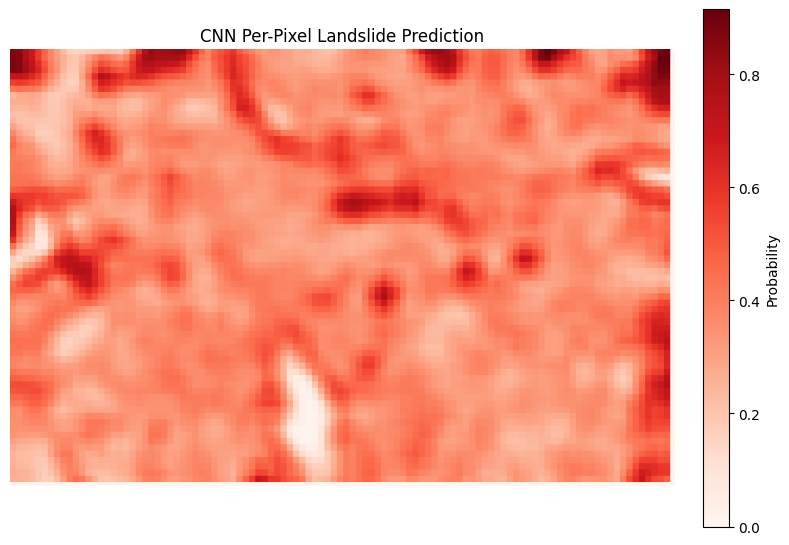


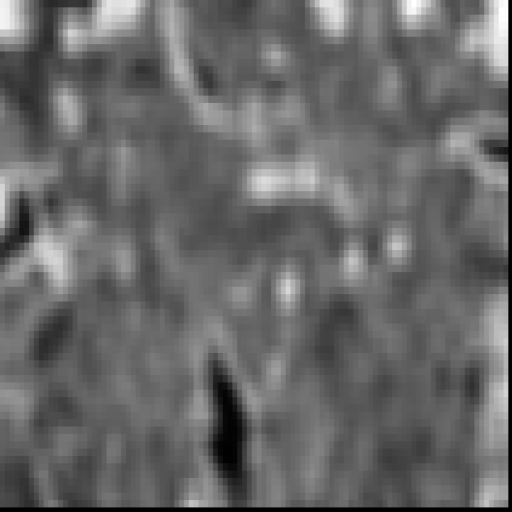

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import folium
from shapely.geometry import box, Polygon, Point
from pyproj import Transformer
from arcgis.gis import GIS
from arcgis.features import FeatureLayer
from PIL import Image
from folium.raster_layers import ImageOverlay

# ------------------------
# 1️⃣ Load CNN model
# ------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define your SmallCNN
class SmallCNN(torch.nn.Module):
    def __init__(self, in_ch=6):
        super().__init__()
        self.conv = torch.nn.Sequential(
            torch.nn.Conv2d(in_ch, 32, 3, padding=1), torch.nn.BatchNorm2d(32), torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(32, 64, 3, padding=1), torch.nn.BatchNorm2d(64), torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(64, 128, 3, padding=1), torch.nn.BatchNorm2d(128), torch.nn.ReLU(),
            torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(128, 256, 3, padding=1), torch.nn.BatchNorm2d(256), torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool2d(1)
        )
        self.fc = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(256, 64), torch.nn.ReLU(), torch.nn.Dropout(0.4),
            torch.nn.Linear(64, 1),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        return self.fc(self.conv(x)).squeeze(1)

# Load model weights
model = SmallCNN(in_ch=6).to(device)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

# ------------------------
# 2️⃣ Load AOI array
# ------------------------
aoi_file = "tile_0.npy"  # your full AOI file
aoi_array = np.load(aoi_file).astype(np.float32)  # [H,W,C]

# ------------------------
# 3️⃣ Patch-wise per-pixel prediction
# ------------------------
def predict_per_pixel(aoi_array, model, patch_size=32, stride=8):
    H, W, C = aoi_array.shape
    pred_probs = np.zeros((H, W), dtype=np.float32)
    counts = np.zeros((H, W), dtype=np.float32)

    device = next(model.parameters()).device
    model.eval()

    for i in range(0, H-patch_size+1, stride):
        for j in range(0, W-patch_size+1, stride):
            patch = aoi_array[i:i+patch_size, j:j+patch_size, :].copy()
            # Normalize per channel
            for b in range(C):
                p2, p98 = np.percentile(patch[...,b], [2,98])
                if p98 - p2 > 0:
                    patch[...,b] = (patch[...,b]-p2)/(p98-p2)
                else:
                    patch[...,b] /= (patch[...,b].max()+1e-6)
            x = torch.from_numpy(patch.transpose(2,0,1)).unsqueeze(0).float().to(device)
            with torch.no_grad():
                prob = model(x).cpu().item()
            pred_probs[i:i+patch_size, j:j+patch_size] += prob
            counts[i:i+patch_size, j:j+patch_size] += 1

    pred_probs /= np.maximum(counts,1)
    return pred_probs

pred_probs = predict_per_pixel(aoi_array, model, patch_size=32, stride=8)

# ------------------------
# 4️⃣ Visualize heatmap
# ------------------------
# fig, ax = plt.figure(figsize=(8,8))
# plt.imshow(pred_probs, cmap='Reds')
# plt.title("CNN Per-Pixel Landslide Prediction")
# plt.axis('off')
# plt.colorbar(label="Probability")
# plt.show()

fig, ax = plt.subplots(figsize=(8, 8))

# Main image
im = ax.imshow(pred_probs, cmap='Reds')
ax.set_title("CNN Per-Pixel Landslide Prediction")
ax.axis('off')

# Add colorbar *aligned with the heatmap height*
cbar = fig.colorbar(im, ax=ax, fraction=0.036, pad=0.04)
cbar.set_label("Probability")

plt.tight_layout()
plt.show()

# ------------------------
# 5️⃣ Load polygons and points
# ------------------------
gis = GIS()
polygon_url = "https://services-ap1.arcgis.com/9R0qvCUXav3QPG1F/arcgis/rest/services/ValidatedLandslides/FeatureServer/2"
points_url = "https://services-ap1.arcgis.com/9R0qvCUXav3QPG1F/arcgis/rest/services/ValidatedLandslides/FeatureServer/0"
polygon_layer = FeatureLayer(polygon_url)
points_layer = FeatureLayer(points_url)

polygons = polygon_layer.query(where="1=1", out_fields="*", result_record_count=2000).features
points = points_layer.query(where="1=1", out_fields="dateoccurence", result_record_count=2000).features

# ------------------------
# 6️⃣ Transform coordinates
# ------------------------
transformer = Transformer.from_crs("epsg:2193","epsg:4326", always_xy=True)

polygon_shapes = []
for poly in polygons:
    for ring in poly.geometry['rings']:
        coords_lonlat = [transformer.transform(x,y) for x,y in ring]
        polygon_shapes.append((Polygon(coords_lonlat), poly.attributes))

point_shapes = []
for pt in points:
    x, y = pt.geometry['x'], pt.geometry['y']
    lon, lat = transformer.transform(x,y)
    point_shapes.append((Point(lon,lat), pt.attributes.get("dateoccurence","Unknown")))

# ------------------------
# 7️⃣ Define AOI polygon
# ------------------------
lat_min, lon_min, lat_max, lon_max = -36.99118, 174.532928, -36.941223, 174.608803
aoi_polygon = box(lon_min, lat_min, lon_max, lat_max)

polygons_in_aoi = [(poly, []) for poly,_ in polygon_shapes if poly.intersects(aoi_polygon)]
points_in_aoi = [(pt,date) for pt,date in point_shapes if aoi_polygon.contains(pt)]

# ------------------------
# 8️⃣ Downsample prediction map for Folium
# ------------------------
pred_norm = (pred_probs - np.nanmin(pred_probs)) / (np.nanmax(pred_probs) - np.nanmin(pred_probs))
pred_norm = np.nan_to_num(pred_norm, nan=0.0, posinf=0.0, neginf=0.0)

H_target, W_target = 512, 512
pred_img = Image.fromarray((pred_norm*255).astype(np.uint8))
pred_img = pred_img.resize((W_target, H_target), Image.BILINEAR)

pred_rgba = Image.new("RGBA", pred_img.size)
pred_rgba.paste(pred_img)
pred_rgba.putalpha(255)  # 50% opacity
pred_rgba.save("pred_overlay.png")

# ------------------------
# 9️⃣ Create Folium map
# ------------------------
m = folium.Map(location=[(lat_min+lat_max)/2, (lon_min+lon_max)/2], zoom_start=13)

# Overlay CNN prediction
ImageOverlay(
    image="pred_overlay.png",
    bounds=[[lat_min, lon_min],[lat_max, lon_max]],
    opacity=0.9,
    interactive=True
).add_to(m)

# Plot polygons
for i, (poly, _) in enumerate(polygons_in_aoi):
    folium.Polygon(
        locations=[(lat, lon) for lon, lat in poly.exterior.coords],
        color='red', weight=3,
        fill=True, fill_color='red', fill_opacity=0.5,
        popup=f"Polygon {i+1}<br><a href='{polygon_url}' target='_blank'>Link</a>"
    ).add_to(m)

# Plot points
for pt, date in points_in_aoi[:100]:
    folium.CircleMarker(
        location=[pt.y, pt.x],
        radius=4, color='green',
        fill=True, fill_color='green',
        fill_opacity=0.8,
        popup=str(date)
    ).add_to(m)

# AOI rectangle
folium.Rectangle(
    bounds=[[lat_min, lon_min],[lat_max, lon_max]],
    color='blue', weight=3,
    fill=False, popup="AOI"
).add_to(m)

# Legend
legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; width: 220px; height: 100px;
background-color: white; z-index:9999; font-size:14px; border:2px solid grey; border-radius:5px; padding: 10px;">
<b>Landslide Legend</b><br>
<span style="background-color:red;display:inline-block;width:15px;height:15px;margin-right:5px;"></span> Landslide Polygon<br>
<span style="background-color:green;display:inline-block;width:15px;height:15px;margin-right:5px;"></span> Landslide Point<br>
<span style="background-color:rgba(255,0,0,0.5);display:inline-block;width:15px;height:15px;margin-right:5px;"></span> CNN Prediction
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

m  # display interactive map
